In [1]:
words = open('D:/Neural Networks/Bigram/names.txt', 'r').read().splitlines()

In [2]:
stoi = {chr(ord('a')+i): i+1 for i in range (26)}
stoi['.'] = 0

itos = {v: k for k, v in stoi.items()}

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [4]:
# Train on whole data
block_size = 8

def build_dataset(words):
   

    X = []
    Y = []

    for w in words:
        context = [0] * block_size  
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random 
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182638, 8]) torch.Size([182638])
torch.Size([22734, 8]) torch.Size([22734])
torch.Size([22774, 8]) torch.Size([22774])


In [5]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out)) / (fan_in ** 0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])
    

class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # params trained by back prop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # buffers (used in inference calulated by running mean)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim = 0, keepdim = True)
            xvar = x.var(dim = 0, keepdim = True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(self.eps + xvar)
        self.out = self.gamma * xhat + self.beta

        with torch.no_grad():
            if self.training:
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out
    
    def parameters(self):
        return [self.gamma] + [self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [6]:
torch.manual_seed(69);

In [7]:
n_emb = 10
n_hidden = 200
vocab_size = 27

model = Sequential([
    Embedding(vocab_size, n_emb),
    Flatten(),
    Linear(n_emb * block_size, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1 # making softmax less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

22097


In [14]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (1, 8, 10)
Flatten : (1, 80)
Linear : (1, 200)
BatchNorm1d : (1, 200)
Tanh : (1, 200)
Linear : (1, 27)


In [8]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None 
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i : 7d}/{max_steps : 7d} : {loss.item() : .4f}")

    lossi.append(loss.log10().item())
    # break



      0/ 200000 :  3.2934
  10000/ 200000 :  2.1806
  20000/ 200000 :  2.5308
  30000/ 200000 :  2.2587
  40000/ 200000 :  1.7107
  50000/ 200000 :  1.9650
  60000/ 200000 :  1.8788
  70000/ 200000 :  1.8734
  80000/ 200000 :  1.8914
  90000/ 200000 :  2.1599
 100000/ 200000 :  2.0053
 110000/ 200000 :  1.9431
 120000/ 200000 :  2.0816
 130000/ 200000 :  2.4836
 140000/ 200000 :  2.3117
 150000/ 200000 :  2.0187
 160000/ 200000 :  1.7380
 170000/ 200000 :  1.5546
 180000/ 200000 :  2.1284
 190000/ 200000 :  1.7264


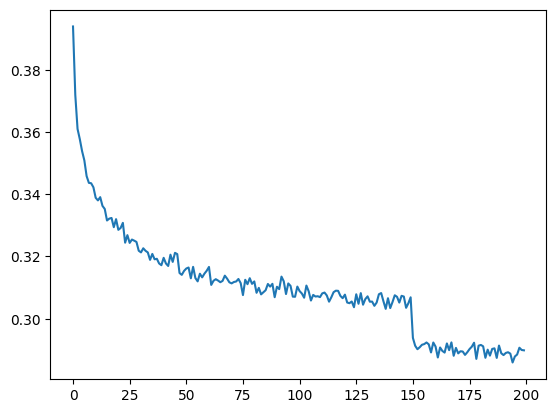

In [9]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [10]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [11]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xtest, Ytest),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9143558740615845
val 2.0303409099578857


In [12]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

demeyno.
jacklynn.
man.
taylan.
linsya.
lalifios.
daza.
calailya.
naviskael.
saaive.
pravy.
yenyisa.
rey.
rut.
nighbange.
dyshau.
karius.
mylally.
marline.
esestyna.


***Now we build Wavenet***

In [31]:
class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # params trained by back prop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # buffers (used in inference calulated by running mean)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 1
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim = True)
            xvar = x.var(dim, keepdim = True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(self.eps + xvar)
        self.out = self.gamma * xhat + self.beta

        with torch.no_grad():
            if self.training:
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out
    
    def parameters(self):
        return [self.gamma] + [self.beta]
    

    
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n 

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, self.n * C)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x 
        return self.out
    
    def parameters(self):
        return []


***Recreating old Vanilla MLP using the new Flatten consecutive layer***

In [22]:
n_emb = 10
n_hidden = 200
vocab_size = 27

model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(block_size),
    Linear(n_emb * block_size, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1 # making softmax less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

22097


In [24]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 80)
Linear : (32, 200)
BatchNorm1d : (32, 200)
Tanh : (32, 200)
Linear : (32, 27)


In [23]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None 
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i : 7d}/{max_steps : 7d} : {loss.item() : .4f}")

    lossi.append(loss.log10().item())
    break



      0/ 200000 :  3.2895


***Finally Wavenet***

In [25]:
n_emb = 10
n_hidden = 100
vocab_size = 27

model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1 # making softmax less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

45597


In [28]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 100)
BatchNorm1d : (32, 4, 100)
Tanh : (32, 4, 100)
FlattenConsecutive : (32, 2, 200)
Linear : (32, 2, 100)
BatchNorm1d : (32, 2, 100)
Tanh : (32, 2, 100)
FlattenConsecutive : (32, 200)
Linear : (32, 100)
BatchNorm1d : (32, 100)
Tanh : (32, 100)
Linear : (32, 27)


In [29]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None 
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i : 7d}/{max_steps : 7d} : {loss.item() : .4f}")

    lossi.append(loss.log10().item())
    # break



      0/ 200000 :  3.2165
  10000/ 200000 :  2.3020
  20000/ 200000 :  1.7118
  30000/ 200000 :  2.0911
  40000/ 200000 :  1.5680
  50000/ 200000 :  1.9570
  60000/ 200000 :  2.0629
  70000/ 200000 :  1.8694
  80000/ 200000 :  1.7879
  90000/ 200000 :  2.1849
 100000/ 200000 :  1.7852
 110000/ 200000 :  1.9279
 120000/ 200000 :  1.7919
 130000/ 200000 :  1.8332
 140000/ 200000 :  1.9032
 150000/ 200000 :  1.8497
 160000/ 200000 :  1.8420
 170000/ 200000 :  2.1823
 180000/ 200000 :  1.6786
 190000/ 200000 :  1.9284


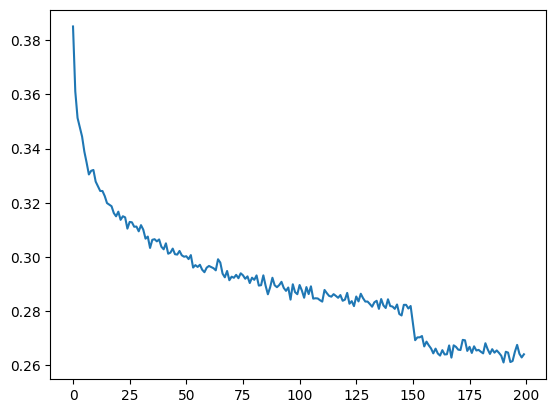

In [30]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [33]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

ungena.
marielan.
emmeren.
imreye.
anah.
ell.
ifers.
undroeyntakhen.
kasin.
mahaq.
mehaga.
monoc.
andraimnkain.
leevanaykcaaclbaovhailideekceesmshou.
mana.
mone.
arlya.
marqo.
dall.
kaylynn.
